# Analyse Exploratoire des Donnees - Services Publics en Ile-de-France

## Objectif
Analyse complete des services publics en Ile-de-France pour construire un indicateur de qualite d'acces aux services publics. Cette analyse couvre les services suivants :
- Education : Ecoles maternelles, elementaires, colleges et enseignement superieur
- Sante : Etablissements hospitaliers
- Securite : Points d'accueil police
- Postes et communications : Bureaux de poste et agences postales
- Culture : Bibliotheques publiques

## Sources de donnees
- parisdata.opendatasoft.com
- data.iledefrance.fr
- data.gouv.fr (via MCP)

## 1. Configuration et Imports

Import des bibliotheques necessaires pour l'analyse de donnees et la visualisation.

In [1]:
# Import des bibliotheques standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
from datetime import datetime
import warnings

# Configuration des affichages
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Configuration completee avec succes")
print(f"Version pandas: {pd.__version__}")
print(f"Version numpy: {np.__version__}")

Configuration completee avec succes
Version pandas: 2.2.3
Version numpy: 1.23.5


## 2. Fonctions Utilitaires pour l'API OpenDataSoft

Fonctions pour interroger les API OpenDataSoft (Paris Data et Data Ile-de-France).

In [2]:
def fetch_opendatasoft_data(base_url, dataset_id, rows=10000):
    """
    Recupere les donnees d'un dataset OpenDataSoft.
    
    Parametres:
    - base_url: URL de base de l'API (ex: 'https://parisdata.opendatasoft.com')
    - dataset_id: Identifiant du dataset
    - rows: Nombre maximum de lignes a recuperer
    
    Retourne:
    - DataFrame pandas avec toutes les donnees
    """
    all_records = []
    start = 0
    batch_size = 100
    
    print(f"Recuperation des donnees de {dataset_id}...")
    
    while True:
        # Construction de l'URL de l'API
        api_url = f"{base_url}/api/records/1.0/search/"
        params = {
            'dataset': dataset_id,
            'rows': batch_size,
            'start': start
        }
        
        try:
            response = requests.get(api_url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            
            records = data.get('records', [])
            if not records:
                break
            
            # Extraction des champs de chaque enregistrement
            for record in records:
                fields = record.get('fields', {})
                all_records.append(fields)
            
            start += batch_size
            
            # Verification si on a recupere tous les enregistrements
            total_count = data.get('nhits', 0)
            if start >= total_count or start >= rows:
                break
                
        except Exception as e:
            print(f"Erreur lors de la recuperation: {e}")
            break
    
    df = pd.DataFrame(all_records)
    print(f"Dataset {dataset_id}: {len(df)} enregistrements recuperes")
    return df

print("Fonctions utilitaires chargees avec succes")

Fonctions utilitaires chargees avec succes


## 3. Chargement des Donnees Scolaires

### 3.1 Secteurs Scolaires - Colleges

In [3]:
# Chargement des donnees des secteurs scolaires colleges
df_colleges = fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='secteurs-scolaires-colleges'
)

print(f"\n--- Apercu des donnees Colleges ---")
print(f"Shape: {df_colleges.shape}")
print(f"\nColonnes disponibles:")
print(df_colleges.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_colleges.head())

Recuperation des donnees de secteurs-scolaires-colleges...
Dataset secteurs-scolaires-colleges: 770 enregistrements recuperes

--- Apercu des donnees Colleges ---
Shape: (770, 14)

Colonnes disponibles:
['adr_etab_1', 'etiquette', 'geo_shape', 'geo_point_2d', 'st_perimeter_shape', 'lib_etab_1', 'st_area_shape', 'id_projet', 'libelle', 'zone_commune', 'type_etabl', 'annee_scol', 'lib_etab_2', 'adr_etab_2']

Premiers enregistrements:


,adr_etab_1,etiquette,geo_shape,geo_point_2d,st_perimeter_shape,lib_etab_1,st_area_shape,id_projet,libelle,zone_commune,type_etabl,annee_scol,lib_etab_2,adr_etab_2
0,22 RUE PAJOL,Secteur du collège AIME CESAIRE,"{'coordinates': [[[[2.3666767804644806, 48.889...","[48.88691574121786, 2.3632661963639463]",11538.987331,AIME CESAIRE,334450.972963,COLLEGES (année scolaire 2020/2021),AIME CESAIRE,0,Collège,2020-2021,NaN,NaN
1,7 RUE JOMARD,Secteur du collège MOZART,"{'coordinates': [[[[2.3835997763116987, 48.893...","[48.89119857936844, 2.380390205482974]",7404.367718,MOZART,202689.702808,COLLEGES (année scolaire 2020/2021),MOZART,0,Collège,2020-2021,NaN,NaN
2,7 RUE JEAN QUARRE,Secteur du collège GUILLAUME BUDE,"{'coordinates': [[[[2.4041585563386025, 48.879...","[48.877853690740686, 2.4000165090945256]",14342.777146,GUILLAUME BUDE,358783.025502,COLLEGES (année scolaire 2020/2021),GUILLAUME BUDE,0,Collège,2020-2021,NaN,NaN
3,5 RUE DE LA JUSSIENNE,Secteur du collège CESAR FRANCK,"{'coordinates': [[[[2.3407065241836604, 48.868...","[48.86751630555303, 2.3449955460211234]",21156.275757,CESAR FRANCK,356767.390405,COLLEGES (année scolaire 2020/2021),CESAR FRANCK,0,Collège,2020-2021,NaN,NaN
4,118 BOULEVARD BESSIERES,Secteur du collège HONORE DE BALZAC,"{'coordinates': [[[[2.3197806369880234, 48.898...","[48.89661319225932, 2.3188696546848058]",19980.972179,HONORE DE BALZAC,569194.032330,COLLEGES (année scolaire 2020/2021),HONORE DE BALZAC,0,Collège,2020-2021,NaN,NaN


### 3.2 Etablissements Scolaires - Ecoles Elementaires

In [4]:
# Chargement des donnees des ecoles elementaires
df_elementaires = fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='etablissements-scolaires-ecoles-elementaires'
)

print(f"\n--- Apercu des donnees Ecoles Elementaires ---")
print(f"Shape: {df_elementaires.shape}")
print(f"\nColonnes disponibles:")
print(df_elementaires.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_elementaires.head())

Recuperation des donnees de etablissements-scolaires-ecoles-elementaires...
Dataset etablissements-scolaires-ecoles-elementaires: 2237 enregistrements recuperes

--- Apercu des donnees Ecoles Elementaires ---
Shape: (2237, 9)

Colonnes disponibles:
['type_etabl', 'adresse', 'arr_libelle', 'arr_insee', 'geo_point_2d', 'id_projet', 'annee_scol', 'libelle', 'geo_shape']

Premiers enregistrements:


,type_etabl,adresse,arr_libelle,arr_insee,geo_point_2d,id_projet,annee_scol,libelle,geo_shape
0,Elémentaire,6 RUE LITTRE,6ème Ardt,75106,"[48.84564322059343, 2.323773103790429]",ELEMENTAIRES (année scolaire 2022/2023),2022-2023,LITTRE (6) ELEM,"{'coordinates': [2.323773103790429, 48.8456432..."
1,Polyvalent,17 CITE CHAMPAGNE,20ème Ardt,75120,"[48.85333032620816, 2.4042089809108966]",ELEMENTAIRES (année scolaire 2022/2023),2022-2023,CHAMPAGNE (17) POLY,"{'coordinates': [2.4042089809108966, 48.853330..."
2,Elémentaire,5 SQUARE ALAIN-FOURNIER,14ème Ardt,75114,"[48.828324298488255, 2.307674934788748]",ELEMENTAIRES (année scolaire 2021/2022),2021-2022,ALAIN-FOURNIER ( 5) ELEM,"{'coordinates': [2.307674934788748, 48.8283242..."
3,Elémentaire,8 RUE PIERRE FONCIN,20ème Ardt,75120,"[48.87135911993382, 2.409709173567288]",ELEMENTAIRES (année scolaire 2021/2022),2021-2022,PIERRE FONCIN (8) ELEM A,"{'coordinates': [2.409709173567288, 48.8713591..."
4,Elémentaire,315 RUE DE CHARENTON,12ème Ardt,75112,"[48.833631434636594, 2.3951603278960523]",ELEMENTAIRES (année scolaire 2021/2022),2021-2022,CHARENTON (315) ELEM,"{'coordinates': [2.3951603278960523, 48.833631..."


### 3.3 Secteurs Scolaires - Maternelles

In [5]:
# Chargement des donnees des secteurs scolaires maternelles
df_maternelles = fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='secteurs-scolaires-maternelles'
)

print(f"\n--- Apercu des donnees Maternelles ---")
print(f"Shape: {df_maternelles.shape}")
print(f"\nColonnes disponibles:")
print(df_maternelles.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_maternelles.head())

Recuperation des donnees de secteurs-scolaires-maternelles...
Dataset secteurs-scolaires-maternelles: 2683 enregistrements recuperes

--- Apercu des donnees Maternelles ---
Shape: (2683, 18)

Colonnes disponibles:
['lib_etab_1', 'id_projet', 'libelle', 'etiquette', 'zone_commune', 'st_area_shape', 'st_perimeter_shape', 'geo_point_2d', 'annee_scol', 'adr_etab_1', 'geo_shape', 'lib_etab_2', 'adr_etab_2', 'type_etabl', 'lib_etab_4', 'adr_etab_3', 'adr_etab_4', 'lib_etab_3']

Premiers enregistrements:


,lib_etab_1,id_projet,libelle,etiquette,zone_commune,st_area_shape,st_perimeter_shape,geo_point_2d,annee_scol,adr_etab_1,geo_shape,lib_etab_2,adr_etab_2,type_etabl,lib_etab_4,adr_etab_3,adr_etab_4,lib_etab_3
0,BIDASSOA (21) MAT,MATERNELLES (année scolaire 2020/2021),BIDASSOA (21) MAT,Secteur de l'école 21 RUE DE LA BIDASSOA,0,97985.387347,6580.143521,"[48.86659445592674, 2.3946671115647016]",2020-2021,21 RUE DE LA BIDASSOA,"{'coordinates': [[[[2.3975986470081954, 48.865...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JEAN MENANS (2) MAT,MATERNELLES (année scolaire 2020/2021),JEAN MENANS (2) MAT,Secteur de l'école 2 RUE JEAN MENANS,0,80302.967029,5163.035554,"[48.88216633729819, 2.379747782045357]",2020-2021,2 RUE JEAN MENANS,"{'coordinates': [[[[2.380506626870043, 48.8817...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ROQUETTE (144) MAT,MATERNELLES (année scolaire 2020/2021),ROQUETTE (144) MAT,Secteur de l'école 144 RUE DE LA ROQUETTE,0,109981.794413,7417.070188,"[48.85759939077132, 2.384015393925117]",2020-2021,144 RUE DE LA ROQUETTE,"{'coordinates': [[[[2.384377800182176, 48.8554...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PERLE (7) MAT,MATERNELLES (année scolaire 2020/2021),PERLE (7) MAT,Secteur de l'école 7 RUE DE LA PERLE,0,256477.819153,11474.563809,"[48.86035818813438, 2.360299997557048]",2020-2021,7 RUE DE LA PERLE,"{'coordinates': [[[[2.3583605766860662, 48.861...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JEANNE D'ARC (32) MAT,MATERNELLES (année scolaire 2020/2021),JEANNE D'ARC (32) MAT,Secteur de l'école 32 PLACE JEANNE D'ARC,0,53089.544031,3712.634006,"[48.830477738906396, 2.3695501849577054]",2020-2021,32 PLACE JEANNE D'ARC,"{'coordinates': [[[[2.3686537097831293, 48.831...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Chargement des Donnees Bibliotheques

Postes publics des bibliotheques parisiennes.

In [6]:
# Chargement des donnees des bibliotheques
df_bibliotheques = fetch_opendatasoft_data(
    base_url='https://opendata.paris.fr',
    dataset_id='postes-publics-des-bibliotheques'
)

print(f"\n--- Apercu des donnees Bibliotheques ---")
print(f"Shape: {df_bibliotheques.shape}")
print(f"\nColonnes disponibles:")
print(df_bibliotheques.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_bibliotheques.head())

Recuperation des donnees de postes-publics-des-bibliotheques...
Dataset postes-publics-des-bibliotheques: 266 enregistrements recuperes

--- Apercu des donnees Bibliotheques ---
Shape: (266, 4)

Colonnes disponibles:
['type_de_poste', 'localisation', 'position', 'nombre_d_ordinateurs']

Premiers enregistrements:


,type_de_poste,localisation,position,nombre_d_ordinateurs
0,Poste Adulte et Jeunesse,Amélie,"[48.8580602, 2.3089956]",2
1,Poste de passage Adulte,Benjamin Rabier,"[48.8873166, 2.3724595]",1
2,Poste de passage Adulte,Georges Brassens,"[48.8350219, 2.3268861]",2
3,Poste Adulte,Germaine Tillion,"[48.8618192, 2.2847432]",10
4,Poste Jeunesse,Vandamme,"[48.8386225, 2.3218739]",3


## 5. Chargement des Donnees Enseignement Superieur

Principaux etablissements d'enseignement superieur en Ile-de-France.

In [7]:
# Chargement des donnees de l'enseignement superieur
df_sup = fetch_opendatasoft_data(
    base_url='https://data.iledefrance.fr',
    dataset_id='principaux-etablissements-denseignement-superieur'
)

print(f"\n--- Apercu des donnees Enseignement Superieur ---")
print(f"Shape: {df_sup.shape}")
print(f"\nColonnes disponibles:")
print(df_sup.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_sup.head())

Recuperation des donnees de principaux-etablissements-denseignement-superieur...
Dataset principaux-etablissements-denseignement-superieur: 86 enregistrements recuperes

--- Apercu des donnees Enseignement Superieur ---
Shape: (86, 92)

Colonnes disponibles:
['coordonnees', 'url_en', 'champ_recherche', 'siren', 'compte_twitter', 'com_code', 'reg_id', 'uai', 'dep_id', 'reg_id_old', 'secteur_d_etablissement', 'identifiant_wikidata', 'localisation', 'identifiant_isni', 'identifiant_eter', 'code_postal_uai', 'url_es', 'type_d_etablissement', 'identifiant_ror', 'uucr_id', 'nom_court', 'siret', 'aca_id', 'element_ror', 'compte_facebook', 'localite_acheminement_uai', 'pays_etranger_acheminement', 'dep_nom', 'aca_nom', 'uucr_nom', 'identifiant_idref', 'com_nom', 'element_wikidata', 'reg_nom', 'statut_juridique_court', 'etablissement_id_paysage', 'reg_nom_old', 'url', 'element_isni', 'article', 'statut_juridique_long', 'uo_lib', 'adresse_uai', 'identifiant_pic', 'scanr', 'compte_linkedin', 'dat

,coordonnees,url_en,champ_recherche,siren,compte_twitter,com_code,reg_id,uai,dep_id,reg_id_old,secteur_d_etablissement,identifiant_wikidata,localisation,identifiant_isni,identifiant_eter,code_postal_uai,url_es,type_d_etablissement,identifiant_ror,uucr_id,nom_court,siret,aca_id,element_ror,compte_facebook,localite_acheminement_uai,pays_etranger_acheminement,dep_nom,aca_nom,uucr_nom,identifiant_idref,com_nom,element_wikidata,reg_nom,statut_juridique_court,etablissement_id_paysage,reg_nom_old,url,element_isni,article,statut_juridique_long,uo_lib,adresse_uai,identifiant_pic,scanr,compte_linkedin,date_creation,rna,vague_contractuelle,compte_youtube,compte_instagram,url_de,identifiant_orgref,texte_de_ref_creation_lib,numero_telephone_uai,compte_flickr,sigle,texte_de_ref_creation,mention_distribution,hal,flux_rss,inscrits,inscrits_2011,inscrits_2017,inscrits_2012,inscrits_2022,inscrits_2015,inscrits_2010,inscrits_2016,inscrits_2018,inscrits_2014,inscrits_2021,uo_lib_officiel,uo_lib_en,inscrits_2020,inscrits_2019,inscrits_2013,compte_france_culture,typologie_d_universites_et_assimiles,compte_github,mooc,compte_pinterest,compte_vimeo,etablissement_experimental,anciens_codes_uai,boite_postale_uai,universites_fusionnees,element_fundref,compte_tumblr,lieu_dit_uai,compte_dailymotion,compte_scoopit
0,"[48.89325, 2.38192]",https://paris-lavillette.archi.fr/en/,École nationale supérieure d'architecture de P...,197518756,https://twitter.com/ENSAPLV,75119,R11,0751875F,D075,R11,public,Q3578185,Île-de-France>Paris>Paris 19e,0000 0001 2322 3651,FR0182,75019,https://paris-lavillette.archi.fr/es/,École,03e2r1r87,UU00851,ENSAPLV,19751875600014,A01,https://ror.org/03e2r1r87,https://www.facebook.com/La-Salle-dExpo-ENSAPL...,PARIS,France,Paris,Paris,Paris,185977049,Paris 19e,https://www.wikidata.org/entity/Q3578185,Île-de-France,Autre établissement public national d'enseigne...,4i3C4,Île-de-France,https://paris-lavillette.archi.fr/,http://www.isni.org/0000 0001 2322 3651,à l',Autre établissement public national d'enseigne...,École nationale supérieure d'architecture de P...,144 RUE DE FLANDRE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[48.87961, 2.328815]",https://en.icam.fr/,Groupe Institut catholique d'arts et métiers;G...,439946427,https://twitter.com/Icam_fr,75109,R11,0755373H,D075,R11,privé,Q3151859,Île-de-France>Paris>Paris 9e,NaN,NaN,75009,NaN,École,01swx2932,UU00851,Groupe ICAM,43994642700044;43994642700036;43994642700028,A01,https://ror.org/01swx2932,https://www.facebook.com/Icam/,Paris,France,Paris,Paris,Paris,NaN,Paris 9e,https://www.wikidata.org/entity/Q3151859,Île-de-France,Association loi de 1901,cZd69,Île-de-France,https://www.icam.fr/,NaN,dans le,Association loi de 1901,Groupe Institut catholique d'arts et métiers,3 Rue de Liège,996649102,https://scanr.enseignementsup-recherche.gouv.f...,https://www.linkedin.com/school/icam-institut-...,1898,W751149975,Vague D,https://www.youtube.com/user/GroupeIcam,https://www.instagram.com/Icam_fr/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[48.866499, 2.338842]",https://www.inha.fr/en/,Institut national d'histoire de l'art;INHA,197546880,https://twitter.com/INHA_Fr,75102,R11,0755026F,D075,R11,public,Q3152376,Île-de-France>Paris>Paris 2e,0000 0001 2285 6289,NaN,75002,NaN,Grand établissement,045cwqj90,UU00851,NaN,19754688000018,A01,https://ror.org/045cwqj90,https://www.facebook.com/Institutnationaldhist...,Paris,France,Paris,Paris,Paris,074593714,Paris 2e,https://www.wikidata.org/entity/Q3152376,Île-de-France,EPSCP,FDijq,Île-de-France,https://www.inha.fr/,http://www.isni.org/0000 0001 2285 6289,à l',"Établissement public à caractère scientifique,...",Institut national d'histoire de l'art,2 rue Vivienne,NaN,https://scanr.enseigne

## 6. Chargement des Donnees Hospitalieres via MCP Data.gouv

Etablissements hospitaliers franciliens via le serveur MCP Data.gouv.fr.

In [8]:
# Note: Les donnees data.gouv.fr necessitent le serveur MCP
# Pour l'instant, nous utiliserons une approche alternative en attendant la configuration MCP

# URL du dataset sur data.gouv.fr
hopitaux_dataset_id = "53699934a3a729239d2036df"  # ID extrait de l'URL data.gouv.fr

print("INFO: Les donnees hospitalieres seront chargees via l'API data.gouv.fr")
print(f"Dataset ID: {hopitaux_dataset_id}")

# Initialisation d'un DataFrame vide pour le moment
# Ce dataset sera recupere via MCP une fois configure
df_hopitaux = pd.DataFrame()

print("\nLe chargement des donnees hospitalieres necessite la configuration du serveur MCP.")
print("Dataset: les-etablissements-hospitaliers-franciliens-idf")

INFO: Les donnees hospitalieres seront chargees via l'API data.gouv.fr
Dataset ID: 53699934a3a729239d2036df

Le chargement des donnees hospitalieres necessite la configuration du serveur MCP.
Dataset: les-etablissements-hospitaliers-franciliens-idf


## 7. Chargement des Donnees Securite (Police) via MCP Data.gouv

Points d'accueil police a Paris via le serveur MCP Data.gouv.fr.

In [9]:
# Dataset police sur data.gouv.fr
police_dataset_id = "5e6df3a78b4c41506e87a9f4"  # ID extrait de l'URL data.gouv.fr

print("INFO: Les donnees des commissariats seront chargees via l'API data.gouv.fr")
print(f"Dataset ID: {police_dataset_id}")

# Initialisation d'un DataFrame vide pour le moment
# Ce dataset sera recupere via MCP une fois configure
df_police = pd.DataFrame()

print("\nLe chargement des donnees police necessite la configuration du serveur MCP.")
print("Dataset: carte-des-points-daccueil-police-a-paris")

INFO: Les donnees des commissariats seront chargees via l'API data.gouv.fr
Dataset ID: 5e6df3a78b4c41506e87a9f4

Le chargement des donnees police necessite la configuration du serveur MCP.
Dataset: carte-des-points-daccueil-police-a-paris


## 8. Chargement des Donnees Postes

Bureaux de poste et agences postales en Ile-de-France (departement 75).

In [10]:
# Chargement des donnees des bureaux de poste
df_postes = fetch_opendatasoft_data(
    base_url='https://data.iledefrance.fr',
    dataset_id='les_bureaux_de_poste_et_agences_postales_en_idf'
)

# Filtrage pour Paris (departement 75)
if 'dep' in df_postes.columns:
    df_postes = df_postes[df_postes['dep'] == '75'].copy()
elif 'code_postal' in df_postes.columns:
    df_postes = df_postes[df_postes['code_postal'].astype(str).str.startswith('75')].copy()

print(f"\n--- Apercu des donnees Postes (Paris) ---")
print(f"Shape: {df_postes.shape}")
print(f"\nColonnes disponibles:")
print(df_postes.columns.tolist())
print(f"\nPremiers enregistrements:")
display(df_postes.head())

Recuperation des donnees de les_bureaux_de_poste_et_agences_postales_en_idf...
Dataset les_bureaux_de_poste_et_agences_postales_en_idf: 1566 enregistrements recuperes

--- Apercu des donnees Postes (Paris) ---
Shape: (241, 24)

Colonnes disponibles:
['geo', 'reverse_geoloc_epci_code_epci', 'reverse_geoloc_commune_insee_com', 'reverse_geoloc_region_insee_reg', 'pays', 'code_insee', 'precision_du_geocodage', 'numero_de_telephone', 'code_postal', 'complement_d_adresse', 'lieu_dit', 'dep', 'adresse', 'reverse_geoloc_region_nom_reg', 'caracteristique_du_site', 'latitude', 'longitude', 'reverse_geoloc_epci_nom_epci', 'reverse_geoloc_departement_insee_dep', 'identifiant_a', 'reverse_geoloc_commune_nom_com', 'reverse_geoloc_departement_nom_dep', 'libelle_du_site', 'localite']

Premiers enregistrements:


,geo,reverse_geoloc_epci_code_epci,reverse_geoloc_commune_insee_com,reverse_geoloc_region_insee_reg,pays,code_insee,precision_du_geocodage,numero_de_telephone,code_postal,complement_d_adresse,lieu_dit,dep,adresse,reverse_geoloc_region_nom_reg,caracteristique_du_site,latitude,longitude,reverse_geoloc_epci_nom_epci,reverse_geoloc_departement_insee_dep,identifiant_a,reverse_geoloc_commune_nom_com,reverse_geoloc_departement_nom_dep,libelle_du_site,localite
57,"[48.8952, 2.3624]",200054781,75118,11,FRANCE,75118,Géocodé au numéro,3631,75018,NaN,NaN,75,5 PLACE PIERRE MAC ORLAN,Île-de-France,Relais poste,48.8952,2.3624,Métropole du Grand Paris,75,12439D,Paris 18e Arrondissement,Paris,RPU PARIS MAC ORLAN RP,PARIS
58,"[48.856098, 2.408479]",200054781,75120,11,FRANCE,75120,Géocodé au numéro,3631,75020,NaN,NaN,75,37 RUE MOURAUD,Île-de-France,Bureau de Poste,48.856098,2.408479,Métropole du Grand Paris,75,14210A,Paris 20e Arrondissement,Paris,PARIS SAINT BLAISE BP,PARIS
59,"[48.847994, 2.319897]",200054781,75106,11,FRANCE,75106,Géocodé au numéro,3631,75006,NaN,NaN,75,111 RUE DE SEVRES,Île-de-France,Bureau de Poste,48.847994,2.319897,Métropole du Grand Paris,75,14226A,Paris 6e Arrondissement,Paris,PARIS SEVRES,PARIS
60,"[48.855496, 2.306928]",200054781,75107,11,FRANCE,75107,Géocodé au numéro,3631,75007,NaN,NaN,75,60 RUE CLER,Île-de-France,Bureau de Poste,48.855496,2.306928,Métropole du Grand Paris,75,14227A,Paris 7e Arrondissement,Paris,PARIS ECOLE MILITAIRE,PARIS
61,"[48.857769, 2.374186]",200054781,75111,11,FRANCE,75111,Géocodé au numéro,3631,75011,NaN,NaN,75,21 RUE BREGUET,Île-de-France,Bureau de Poste,48.857769,2.374186,Métropole du Grand Paris,75,14231A,Paris 11e Arrondissement,Paris,PARIS POPINCOURT BP,PARIS


## 9. Exploration des Structures de Donnees

Analyse detaillee de la structure de chaque dataset : dimensions, types de donnees, et apercu.

In [11]:
# Dictionnaire de tous les datasets
datasets = {
    'Colleges': df_colleges,
    'Ecoles Elementaires': df_elementaires,
    'Maternelles': df_maternelles,
    'Bibliotheques': df_bibliotheques,
    'Enseignement Superieur': df_sup,
    'Hopitaux': df_hopitaux,
    'Police': df_police,
    'Postes': df_postes
}

# Creation d'un tableau recapitulatif
summary_data = []
for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Nombre de lignes': len(df),
        'Nombre de colonnes': len(df.columns),
        'Taille memoire (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    })

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("RESUME DES DATASETS CHARGES")
print("=" * 80)
display(df_summary)

# Details pour chaque dataset
print("\n" + "=" * 80)
print("DETAILS PAR DATASET")
print("=" * 80)

for name, df in datasets.items():
    if len(df) > 0:
        print(f"\n>>> {name}")
        print(f"    Shape: {df.shape}")
        print(f"    Types de donnees:")
        print(df.dtypes.value_counts().to_string().replace('\n', '\n    '))

RESUME DES DATASETS CHARGES


,Dataset,Nombre de lignes,Nombre de colonnes,Taille memoire (MB)
0,Colleges,770,14,0.72
1,Ecoles Elementaires,2237,9,1.73
2,Maternelles,2683,18,2.86
3,Bibliotheques,266,4,0.07
4,Enseignement Superieur,86,92,0.44
5,Hopitaux,0,0,0.00
6,Police,0,0,0.00
7,Postes,241,24,0.29



DETAILS PAR DATASET

>>> Colleges
    Shape: (770, 14)
    Types de donnees:
object     11
    float64     2
    int64       1

>>> Ecoles Elementaires
    Shape: (2237, 9)
    Types de donnees:
object    8
    int64     1

>>> Maternelles
    Shape: (2683, 18)
    Types de donnees:
object     15
    float64     2
    int64       1

>>> Bibliotheques
    Shape: (266, 4)
    Types de donnees:
object    3
    int64     1

>>> Enseignement Superieur
    Shape: (86, 92)
    Types de donnees:
object     87
    float64     5

>>> Postes
    Shape: (241, 24)
    Types de donnees:
object    17
    int64      7


## 10. Analyse des Valeurs Manquantes

Identification et quantification des valeurs manquantes dans chaque dataset.

In [12]:
# Fonction pour analyser les valeurs manquantes
def analyze_missing_values(df, dataset_name):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Parametres:
    - df: DataFrame a analyser
    - dataset_name: Nom du dataset pour l'affichage
    """
    if len(df) == 0:
        print(f"\n{dataset_name}: Dataset vide")
        return
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Colonne': missing.index,
        'Valeurs manquantes': missing.values,
        'Pourcentage': missing_pct.values
    })
    
    missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Pourcentage', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n>>> {dataset_name}")
        print(f"    Total de lignes: {len(df)}")
        print(f"    Colonnes avec valeurs manquantes: {len(missing_df)} sur {len(df.columns)}")
        print(f"\n    Top 10 des colonnes avec le plus de valeurs manquantes:")
        display(missing_df.head(10))
    else:
        print(f"\n>>> {dataset_name}: Aucune valeur manquante detectee")

# Analyse pour chaque dataset
print("=" * 80)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 80)

for name, df in datasets.items():
    analyze_missing_values(df, name)

ANALYSE DES VALEURS MANQUANTES

>>> Colleges
    Total de lignes: 770
    Colonnes avec valeurs manquantes: 3 sur 14

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
12,lib_etab_2,749,97.272727
13,adr_etab_2,749,97.272727
0,adr_etab_1,24,3.116883



>>> Ecoles Elementaires
    Total de lignes: 2237
    Colonnes avec valeurs manquantes: 1 sur 9

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
6,annee_scol,71,3.173894



>>> Maternelles
    Total de lignes: 2683
    Colonnes avec valeurs manquantes: 9 sur 18

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
14,lib_etab_4,2655,98.956392
16,adr_etab_4,2655,98.956392
15,adr_etab_3,2573,95.900112
17,lib_etab_3,2572,95.862840
12,adr_etab_2,2362,88.035781
11,lib_etab_2,2361,87.998509
13,type_etabl,384,14.312337
9,adr_etab_1,59,2.199031
0,lib_etab_1,3,0.111815



>>> Bibliotheques: Aucune valeur manquante detectee

>>> Enseignement Superieur
    Total de lignes: 86
    Colonnes avec valeurs manquantes: 66 sur 92

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
91,compte_scoopit,85,98.837209
88,compte_tumblr,85,98.837209
77,compte_france_culture,85,98.837209
86,universites_fusionnees,85,98.837209
51,url_de,85,98.837209
79,compte_github,84,97.674419
16,url_es,84,97.674419
89,lieu_dit_uai,84,97.674419
90,compte_dailymotion,83,96.511628
81,compte_pinterest,83,96.511628



Hopitaux: Dataset vide

Police: Dataset vide

>>> Postes
    Total de lignes: 241
    Colonnes avec valeurs manquantes: 3 sur 24

    Top 10 des colonnes avec le plus de valeurs manquantes:


,Colonne,Valeurs manquantes,Pourcentage
10,lieu_dit,241,100.000000
9,complement_d_adresse,151,62.655602
6,precision_du_geocodage,56,23.236515


### 10.1 Visualisation des Valeurs Manquantes

Graphiques pour visualiser les patterns de donnees manquantes.

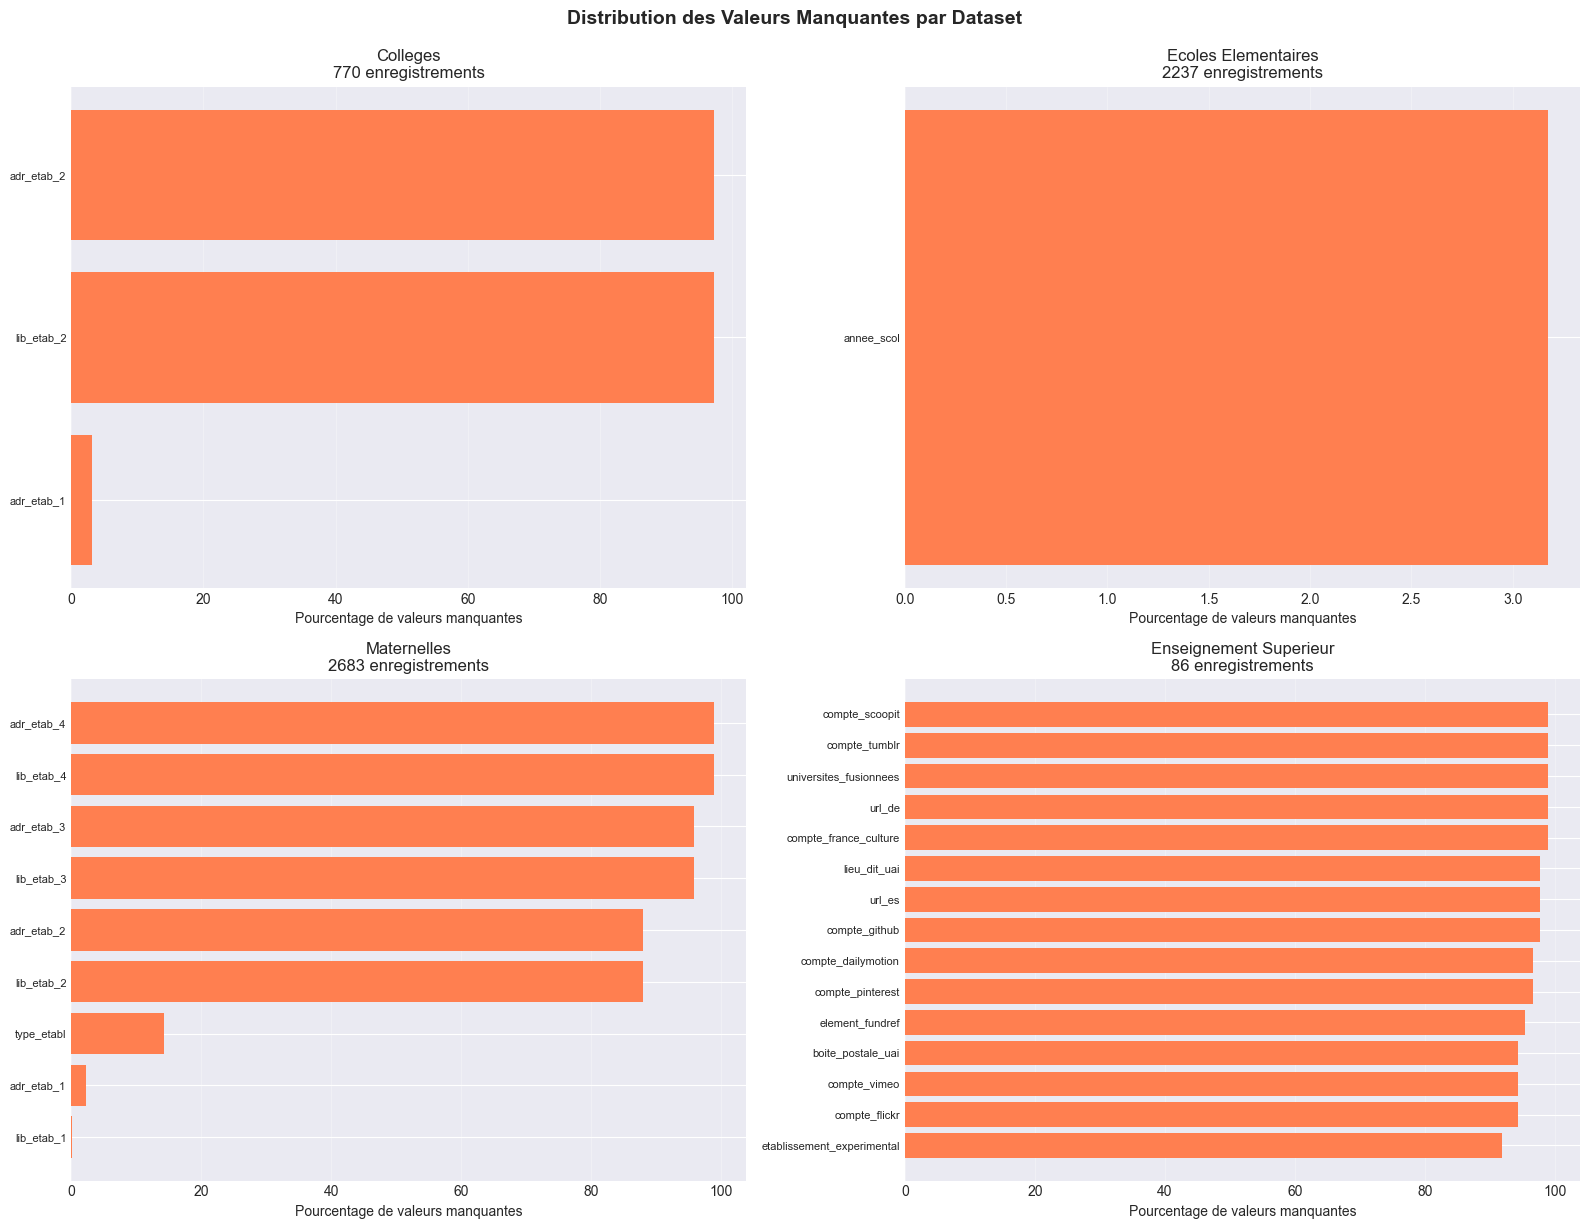

In [13]:
# Visualisation des valeurs manquantes pour les datasets non vides
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_idx = 0
for name, df in datasets.items():
    if len(df) > 0 and plot_idx < 4:
        missing_pct = (df.isnull().sum() / len(df)) * 100
        missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
        
        if len(missing_pct) > 0:
            # Limiter aux 15 colonnes avec le plus de valeurs manquantes
            missing_pct = missing_pct.tail(15)
            
            axes[plot_idx].barh(range(len(missing_pct)), missing_pct.values, color='coral')
            axes[plot_idx].set_yticks(range(len(missing_pct)))
            axes[plot_idx].set_yticklabels(missing_pct.index, fontsize=8)
            axes[plot_idx].set_xlabel('Pourcentage de valeurs manquantes')
            axes[plot_idx].set_title(f'{name}\n{len(df)} enregistrements')
            axes[plot_idx].grid(axis='x', alpha=0.3)
            
            plot_idx += 1

# Masquer les axes non utilises
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Distribution des Valeurs Manquantes par Dataset', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 11. Statistiques Descriptives par Type de Service

Calcul des statistiques descriptives pour chaque categorie de service public.

In [15]:
# Statistiques descriptives pour chaque dataset
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES PAR CATEGORIE DE SERVICE")
print("=" * 80)

for name, df in datasets.items():
    if len(df) > 0:
        print(f"\n{'=' * 80}")
        print(f">>> {name.upper()}")
        print(f"{'=' * 80}")
        
        # Statistiques de base
        print(f"\nNombre total d'etablissements: {len(df)}")
        
        # Colonnes numeriques
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            print(f"\nStatistiques pour les colonnes numeriques:")
            display(df[numeric_cols].describe())
        
        # Colonnes categoriques
        categorical_cols = df.select_dtypes(include=['object']).columns
        if len(categorical_cols) > 0:
            print(f"\nApercu des colonnes categoriques (5 premieres):")
            for col in categorical_cols[:5]:
                try:
                    unique_count = df[col].nunique()
                    print(f"\n  {col}:")
                    print(f"    Valeurs uniques: {unique_count}")
                    if unique_count < 20:
                        value_counts = df[col].value_counts().head(10)
                        print(f"    Repartition:")
                        for val, count in value_counts.items():
                            print(f"      - {val}: {count}")
                except Exception as e:
                    print(f"\n  {col}:")
                    print(f"    Erreur lors de l'analyse: {type(e).__name__}")

STATISTIQUES DESCRIPTIVES PAR CATEGORIE DE SERVICE

>>> COLLEGES

Nombre total d'etablissements: 770

Statistiques pour les colonnes numeriques:


,st_perimeter_shape,st_area_shape,zone_commune
count,770.000000,7.700000e+02,770.000000
mean,23156.126041,5.821542e+05,0.027273
std,13495.969128,5.611424e+05,0.162983
min,6737.321390,1.356989e+05,0.000000
25%,14918.978142,3.381824e+05,0.000000
50%,21080.493548,4.838005e+05,0.000000
75%,26804.117454,6.657687e+05,0.000000
max,111330.700081,8.513621e+06,1.000000



Apercu des colonnes categoriques (5 premieres):

  adr_etab_1:
    Valeurs uniques: 111

  etiquette:
    Valeurs uniques: 110

  geo_shape:
    Erreur lors de l'analyse: TypeError

  geo_point_2d:
    Erreur lors de l'analyse: TypeError

  lib_etab_1:
    Valeurs uniques: 110

>>> ECOLES ELEMENTAIRES

Nombre total d'etablissements: 2237

Statistiques pour les colonnes numeriques:


,arr_insee
count,2237.000000
mean,75114.013411
std,4.985919
min,75101.000000
25%,75111.000000
50%,75115.000000
75%,75118.000000
max,75120.000000



Apercu des colonnes categoriques (5 premieres):

  type_etabl:
    Valeurs uniques: 2
    Repartition:
      - Elémentaire: 1670
      - Polyvalent: 567

  adresse:
    Valeurs uniques: 658

  arr_libelle:
    Valeurs uniques: 20

  geo_point_2d:
    Erreur lors de l'analyse: TypeError

  id_projet:
    Valeurs uniques: 6
    Repartition:
      - ELEMENTAIRES (année scolaire 2022/2023): 426
      - ELEMENTAIRES (année scolaire 2023/2024): 363
      - ELEMENTAIRES (année scolaire 2021/2022): 362
      - ELEMENTAIRES (année scolaire 2024/2025): 362
      - ELEMENTAIRES (année scolaire 2025/2026): 362
      - ELEMENTAIRES (année scolaire 2026/2027): 362

>>> MATERNELLES

Nombre total d'etablissements: 2683

Statistiques pour les colonnes numeriques:


...


Apercu des colonnes categoriques (5 premieres):

  type_de_poste:
    Valeurs uniques: 10
    Repartition:
      - Catalogue: 70
      - Poste de passage Adulte: 51
      - Poste Adulte: 47
      - Poste Jeunesse: 40
      - Poste de passage Jeunesse: 17
      - Poste Adulte et Jeunesse: 14
      - Poste animation: 13
      - Poste chercheur: 12
      - Poste animation Adulte: 1
      - Poste chercheur DVD: 1

  localisation:
    Valeurs uniques: 72

  position:
    Erreur lors de l'analyse: TypeError

>>> ENSEIGNEMENT SUPERIEUR

Nombre total d'etablissements: 86

Statistiques pour les colonnes numeriques:


,inscrits_2022,inscrits_2018,inscrits_2021,inscrits_2020,inscrits_2019
count,30.000000,21.000000,30.000000,29.00000,29.000000
mean,15110.666667,12794.761905,15253.100000,14757.37931,14708.896552
std,16705.750260,14669.822071,16682.061965,16299.88162,16167.973878
min,144.000000,148.000000,147.000000,144.00000,147.000000
25%,1224.000000,850.000000,1204.250000,963.00000,912.000000
50%,8649.000000,5925.000000,8815.500000,7116.00000,9461.000000
75%,21924.500000,21348.000000,22480.000000,23233.00000,23148.000000
max,58242.000000,50232.000000,56099.000000,51591.00000,53979.000000



Apercu des colonnes categoriques (5 premieres):

  coordonnees:
    Erreur lors de l'analyse: TypeError

  url_en:
    Valeurs uniques: 61

  champ_recherche:
    Valeurs uniques: 86

  siren:
    Valeurs uniques: 83

  compte_twitter:
    Valeurs uniques: 70

>>> POSTES

Nombre total d'etablissements: 241

Statistiques pour les colonnes numeriques:


,reverse_geoloc_epci_code_epci,reverse_geoloc_commune_insee_com,reverse_geoloc_region_insee_reg,code_insee,numero_de_telephone,code_postal,reverse_geoloc_departement_insee_dep
count,2.410000e+02,241.000000,241.0,241.000000,241.0,241.000000,241.000000
mean,2.000548e+08,75181.435685,11.0,75112.717842,3631.0,75016.037344,75.070539
std,2.056792e+02,1090.532984,0.0,4.953456,0.0,19.201200,1.095066
min,2.000548e+08,75056.000000,11.0,75101.000000,3631.0,75001.000000,75.000000
25%,2.000548e+08,75109.000000,11.0,75110.000000,3631.0,75010.000000,75.000000
50%,2.000548e+08,75113.000000,11.0,75113.000000,3631.0,75013.000000,75.000000
75%,2.000548e+08,75117.000000,11.0,75117.000000,3631.0,75017.000000,75.000000
max,2.000580e+08,92040.000000,11.0,75120.000000,3631.0,75116.000000,92.000000



Apercu des colonnes categoriques (5 premieres):

  geo:
    Erreur lors de l'analyse: TypeError

  pays:
    Valeurs uniques: 1
    Repartition:
      - FRANCE: 241

  precision_du_geocodage:
    Valeurs uniques: 1
    Repartition:
      - Géocodé au numéro: 185

  complement_d_adresse:
    Valeurs uniques: 82

  lieu_dit:
    Valeurs uniques: 0
    Repartition:


## 12. Distribution Geographique des Services

Analyse de la repartition geographique des differents services publics.

In [16]:
# Fonction pour extraire les informations geographiques
def extract_geo_info(df, dataset_name):
    """
    Extrait et analyse les informations geographiques d'un dataset.
    
    Parametres:
    - df: DataFrame a analyser
    - dataset_name: Nom du dataset
    
    Retourne:
    - DataFrame avec les informations geographiques agregees
    """
    if len(df) == 0:
        return None
    
    # Recherche de colonnes geographiques communes
    geo_columns = []
    
    for col in df.columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['arr', 'arrondissement', 'commune', 'ville', 'cp', 'postal']):
            geo_columns.append(col)
    
    if not geo_columns:
        return None
    
    # Utiliser la premiere colonne geographique trouvee
    geo_col = geo_columns[0]
    geo_dist = df[geo_col].value_counts().reset_index()
    geo_dist.columns = ['Zone', 'Nombre']
    geo_dist['Service'] = dataset_name
    
    return geo_dist

# Extraction et agregation des informations geographiques
geo_distributions = []

for name, df in datasets.items():
    if len(df) > 0:
        geo_info = extract_geo_info(df, name)
        if geo_info is not None:
            geo_distributions.append(geo_info)

if geo_distributions:
    print("=" * 80)
    print("DISTRIBUTION GEOGRAPHIQUE DES SERVICES")
    print("=" * 80)
    
    for geo_df in geo_distributions:
        service_name = geo_df['Service'].iloc[0]
        print(f"\n>>> {service_name}")
        print(f"    Total de zones: {len(geo_df)}")
        print(f"    Top 10 des zones:")
        display(geo_df.head(10))
else:
    print("Aucune information geographique trouvee dans les datasets")

DISTRIBUTION GEOGRAPHIQUE DES SERVICES

>>> Colleges
    Total de zones: 2
    Top 10 des zones:


,Zone,Nombre,Service
0,0,749,Colleges
1,1,21,Colleges



>>> Ecoles Elementaires
    Total de zones: 20
    Top 10 des zones:


,Zone,Nombre,Service
0,20ème Ardt,261,Ecoles Elementaires
1,18ème Ardt,242,Ecoles Elementaires
2,19ème Ardt,239,Ecoles Elementaires
3,13ème Ardt,224,Ecoles Elementaires
4,15ème Ardt,171,Ecoles Elementaires
5,17ème Ardt,159,Ecoles Elementaires
6,12ème Ardt,127,Ecoles Elementaires
7,14ème Ardt,110,Ecoles Elementaires
8,11ème Ardt,108,Ecoles Elementaires
9,16ème Ardt,104,Ecoles Elementaires



>>> Maternelles
    Total de zones: 2
    Top 10 des zones:


,Zone,Nombre,Service
0,0,2362,Maternelles
1,1,321,Maternelles



>>> Enseignement Superieur
    Total de zones: 61
    Top 10 des zones:


,Zone,Nombre,Service
0,75006,8,Enseignement Superieur
1,75005,4,Enseignement Superieur
2,75019,3,Enseignement Superieur
3,75014,3,Enseignement Superieur
4,94200,2,Enseignement Superieur
5,92916,2,Enseignement Superieur
6,77455,2,Enseignement Superieur
7,93200,2,Enseignement Superieur
8,78000,2,Enseignement Superieur
9,75013,2,Enseignement Superieur



>>> Postes
    Total de zones: 22
    Top 10 des zones:


,Zone,Nombre,Service
0,75115,19,Postes
1,75113,19,Postes
2,75114,19,Postes
3,75119,19,Postes
4,75117,17,Postes
5,75111,17,Postes
6,75118,16,Postes
7,75116,15,Postes
8,75110,12,Postes
9,75120,12,Postes


### 12.1 Visualisation de la Distribution Geographique

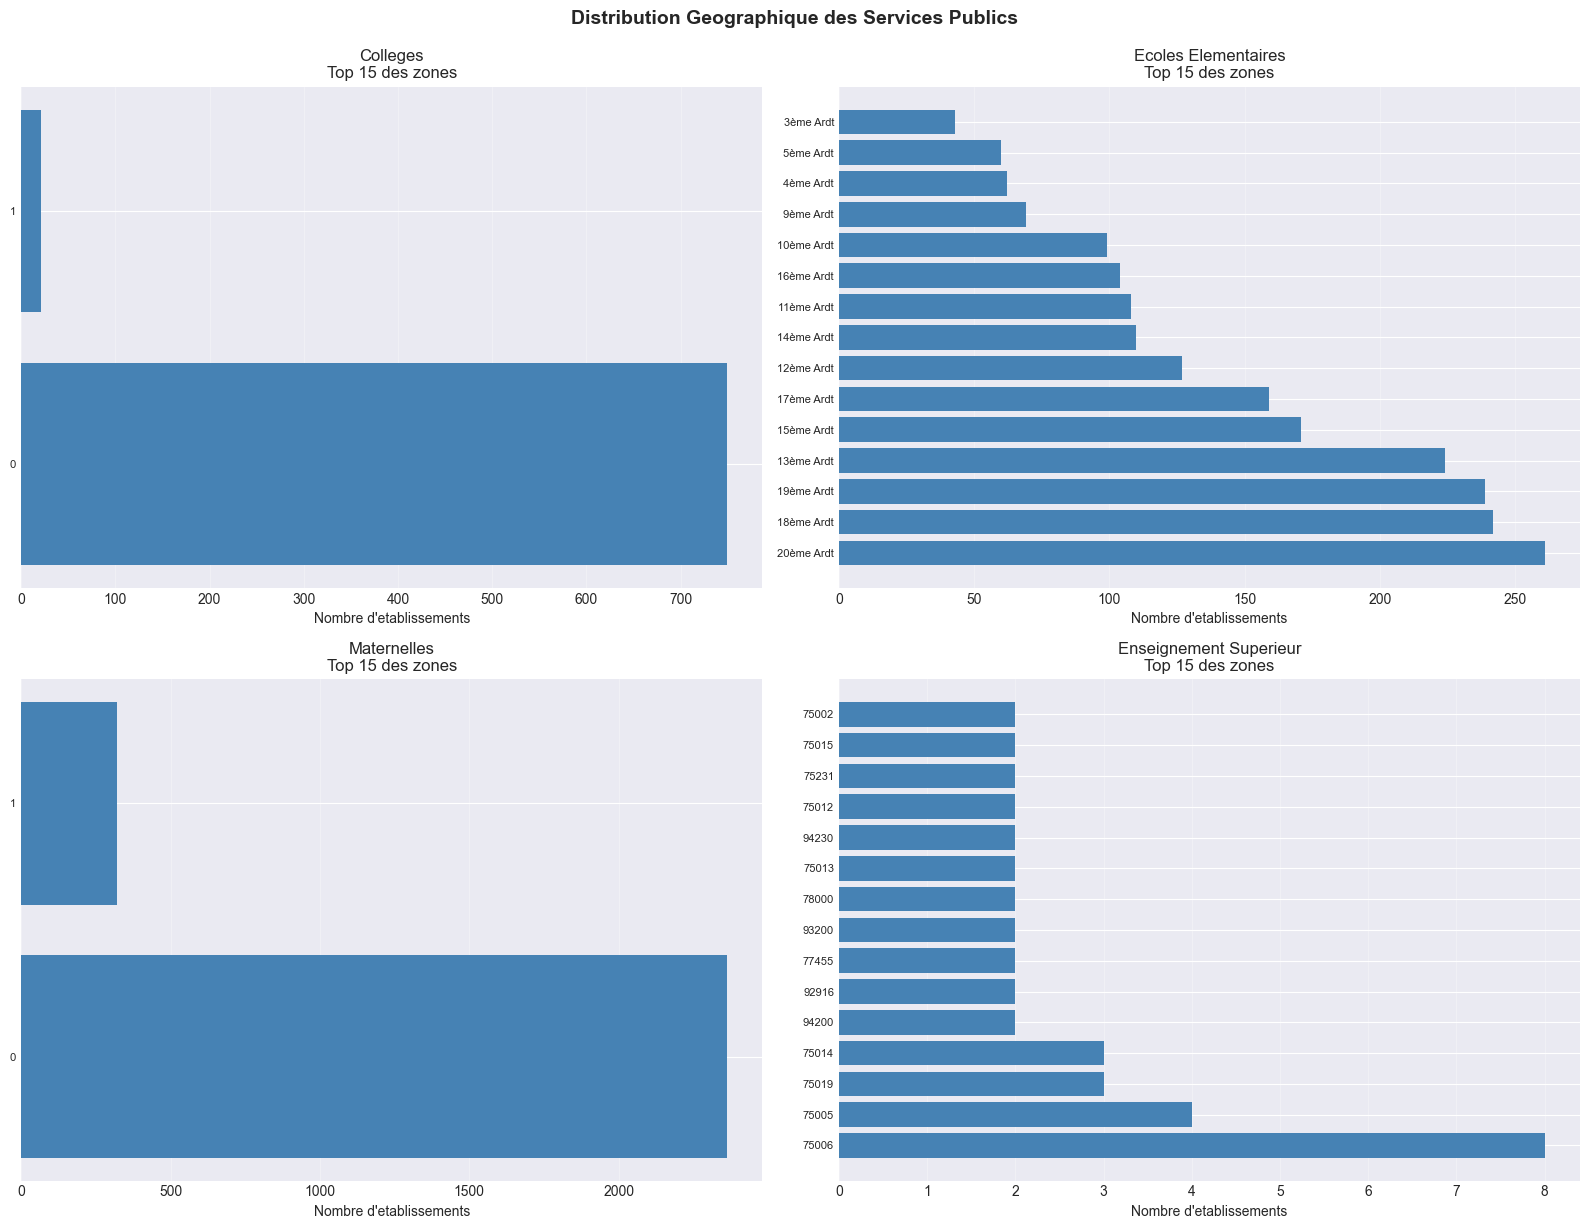

In [17]:
# Visualisation de la distribution geographique
if geo_distributions:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, geo_df in enumerate(geo_distributions[:4]):
        if idx < len(axes):
            service_name = geo_df['Service'].iloc[0]
            top_zones = geo_df.head(15)
            
            axes[idx].barh(range(len(top_zones)), top_zones['Nombre'].values, color='steelblue')
            axes[idx].set_yticks(range(len(top_zones)))
            axes[idx].set_yticklabels(top_zones['Zone'].values, fontsize=8)
            axes[idx].set_xlabel('Nombre d\'etablissements')
            axes[idx].set_title(f'{service_name}\nTop 15 des zones')
            axes[idx].grid(axis='x', alpha=0.3)
    
    # Masquer les axes non utilises
    for idx in range(len(geo_distributions), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Distribution Geographique des Services Publics', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Aucune donnee geographique a visualiser")

## 13. Analyse de la Densite des Services par Arrondissement

Calcul et visualisation de la densite de chaque type de service public par arrondissement parisien.

In [18]:
# Fonction pour extraire le numero d'arrondissement
def extract_arrondissement(df):
    """
    Extrait le numero d'arrondissement d'un DataFrame.
    Recherche dans les colonnes contenant 'arr' ou les codes postaux.
    
    Retourne:
    - Serie pandas avec les numeros d'arrondissement
    """
    arr_col = None
    
    # Recherche de colonne d'arrondissement
    for col in df.columns:
        col_lower = col.lower()
        if 'arr' in col_lower and 'insee' not in col_lower:
            arr_col = col
            break
    
    if arr_col:
        # Extraction des numeros d'arrondissement
        arr_series = df[arr_col].astype(str)
        # Extraction des chiffres pour obtenir le numero
        arr_series = arr_series.str.extract(r'(\d+)')[0]
        return arr_series
    
    # Si pas de colonne arr, chercher dans code postal
    for col in df.columns:
        col_lower = col.lower()
        if 'postal' in col_lower or 'cp' in col_lower:
            cp_series = df[col].astype(str)
            # Extraire les 2 derniers chiffres du code postal pour Paris
            arr_series = cp_series.str.extract(r'75(\d{2})')[0]
            return arr_series
    
    return None

# Creation d'un tableau de densite par arrondissement
densite_data = []

for name, df in datasets.items():
    if len(df) > 0:
        arr_series = extract_arrondissement(df)
        if arr_series is not None:
            arr_counts = arr_series.value_counts().sort_index()
            for arr, count in arr_counts.items():
                if pd.notna(arr):
                    densite_data.append({
                        'Arrondissement': f"75{str(arr).zfill(2)}",
                        'Service': name,
                        'Nombre': count
                    })

if densite_data:
    df_densite = pd.DataFrame(densite_data)
    
    print("=" * 80)
    print("DENSITE DES SERVICES PAR ARRONDISSEMENT")
    print("=" * 80)
    print(f"\nNombre total d'observations: {len(df_densite)}")
    
    # Tableau pivot pour une vue d'ensemble
    pivot_densite = df_densite.pivot_table(
        index='Arrondissement',
        columns='Service',
        values='Nombre',
        fill_value=0
    )
    
    print("\n>>> Tableau recapitulatif par arrondissement:")
    display(pivot_densite)
    
    # Total par service
    print("\n>>> Total par type de service:")
    total_by_service = df_densite.groupby('Service')['Nombre'].sum().sort_values(ascending=False)
    display(total_by_service)
else:
    print("Impossible de calculer la densite par arrondissement")

DENSITE DES SERVICES PAR ARRONDISSEMENT

Nombre total d'observations: 35

>>> Tableau recapitulatif par arrondissement:


Service,Ecoles Elementaires,Enseignement Superieur,Postes
Arrondissement,,,
7500,0.0,16.0,59.0
7501,15.0,15.0,162.0
7502,37.0,0.0,12.0
7503,43.0,1.0,0.0
7504,62.0,0.0,0.0
7505,60.0,0.0,0.0
7506,30.0,0.0,0.0
7507,38.0,0.0,0.0
7508,39.0,0.0,0.0



>>> Total par type de service:


Service
Ecoles Elementaires       2237
Postes                     241
Enseignement Superieur      41
Name: Nombre, dtype: int64

### 13.1 Visualisation de la Densite par Arrondissement

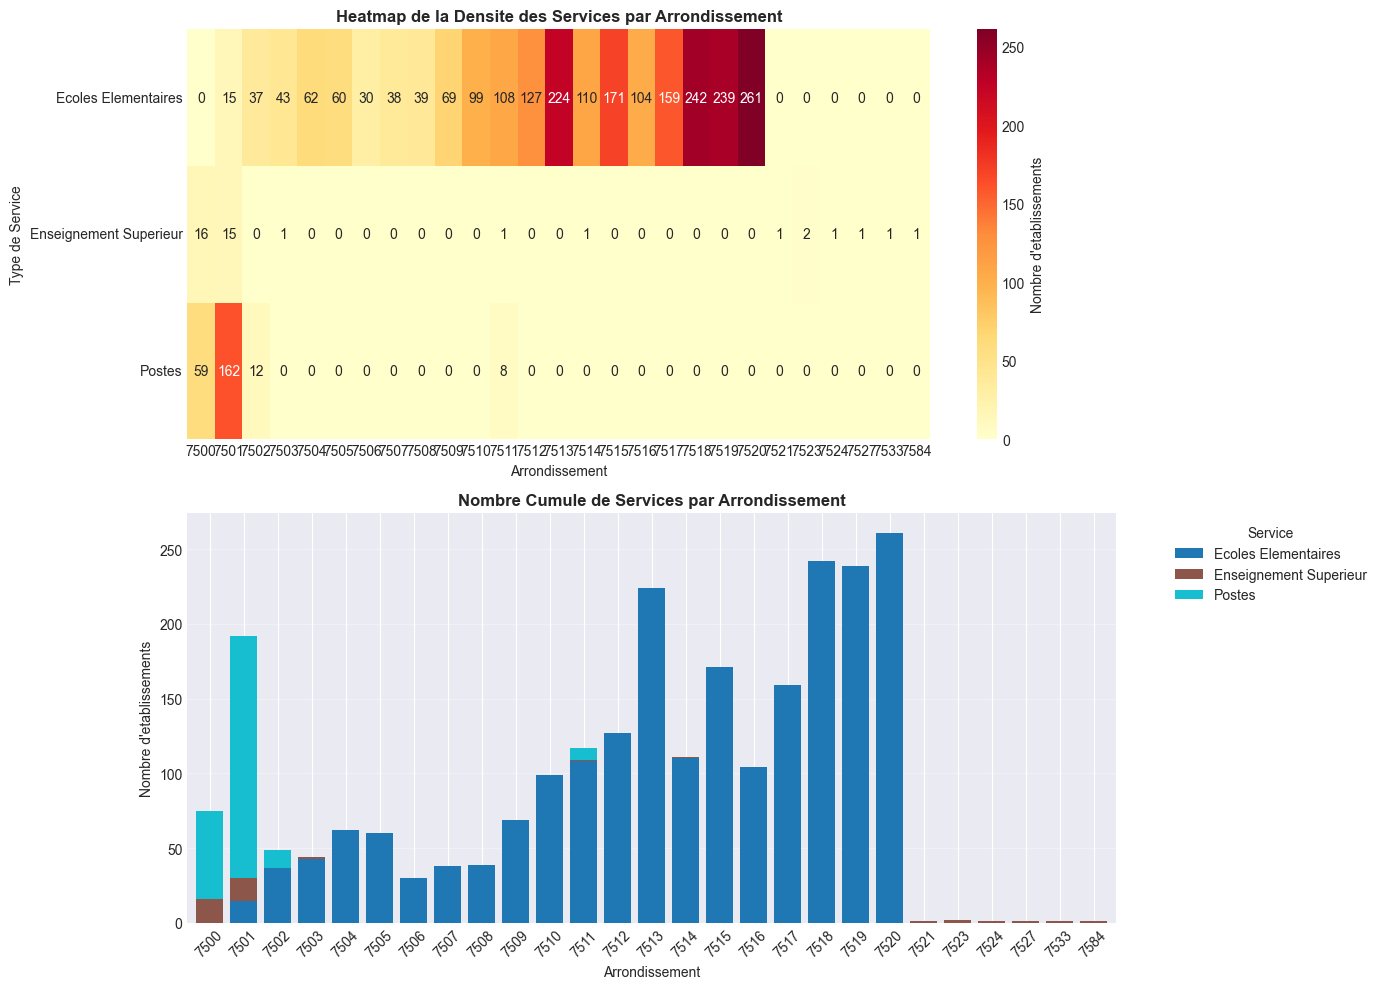

In [19]:
# Visualisation de la densite par arrondissement
if densite_data:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Graphique 1: Heatmap de la densite
    if len(pivot_densite) > 0:
        sns.heatmap(pivot_densite.T, annot=True, fmt='g', cmap='YlOrRd', 
                    cbar_kws={'label': 'Nombre d\'etablissements'}, ax=axes[0])
        axes[0].set_title('Heatmap de la Densite des Services par Arrondissement', 
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Arrondissement')
        axes[0].set_ylabel('Type de Service')
    
    # Graphique 2: Graphique en barres empilees
    pivot_densite.plot(kind='bar', stacked=True, ax=axes[1], 
                       colormap='tab10', width=0.8)
    axes[1].set_title('Nombre Cumule de Services par Arrondissement', 
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Arrondissement')
    axes[1].set_ylabel('Nombre d\'etablissements')
    axes[1].legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune donnee de densite a visualiser")

## 14. Analyse des Coordonnees Geographiques

Extraction et analyse des coordonnees GPS des etablissements.

In [20]:
# Fonction pour extraire les coordonnees geographiques
def extract_coordinates(df, dataset_name):
    """
    Extrait les coordonnees latitude et longitude d'un DataFrame.
    
    Retourne:
    - DataFrame avec Service, Latitude, Longitude
    """
    coords_data = []
    
    # Recherche de colonnes de coordonnees
    lat_col = None
    lon_col = None
    geo_col = None
    
    for col in df.columns:
        col_lower = col.lower()
        if 'lat' in col_lower and 'latitude' not in col_lower:
            lat_col = col
        elif 'latitude' in col_lower:
            lat_col = col
        elif 'lon' in col_lower and 'longitude' not in col_lower:
            lon_col = col
        elif 'longitude' in col_lower:
            lon_col = col
        elif 'geo' in col_lower and 'point' in col_lower:
            geo_col = col
    
    # Extraction des coordonnees
    if lat_col and lon_col:
        for idx, row in df.iterrows():
            try:
                lat = float(row[lat_col])
                lon = float(row[lon_col])
                if pd.notna(lat) and pd.notna(lon):
                    coords_data.append({
                        'Service': dataset_name,
                        'Latitude': lat,
                        'Longitude': lon
                    })
            except:
                continue
    elif geo_col:
        for idx, row in df.iterrows():
            try:
                geo_value = row[geo_col]
                if isinstance(geo_value, (list, tuple)) and len(geo_value) == 2:
                    lat, lon = float(geo_value[0]), float(geo_value[1])
                    coords_data.append({
                        'Service': dataset_name,
                        'Latitude': lat,
                        'Longitude': lon
                    })
            except:
                continue
    
    return pd.DataFrame(coords_data) if coords_data else None

# Extraction des coordonnees pour tous les datasets
all_coords = []

for name, df in datasets.items():
    if len(df) > 0:
        coords_df = extract_coordinates(df, name)
        if coords_df is not None and len(coords_df) > 0:
            all_coords.append(coords_df)

if all_coords:
    df_all_coords = pd.concat(all_coords, ignore_index=True)
    
    print("=" * 80)
    print("ANALYSE DES COORDONNEES GEOGRAPHIQUES")
    print("=" * 80)
    print(f"\nTotal d'etablissements geolocalises: {len(df_all_coords)}")
    
    # Statistiques par service
    coords_by_service = df_all_coords.groupby('Service').agg({
        'Latitude': ['count', 'mean', 'std', 'min', 'max'],
        'Longitude': ['mean', 'std', 'min', 'max']
    }).round(6)
    
    print("\n>>> Statistiques des coordonnees par service:")
    display(coords_by_service)
else:
    print("Aucune coordonnee geographique trouvee dans les datasets")

ANALYSE DES COORDONNEES GEOGRAPHIQUES

Total d'etablissements geolocalises: 5931

>>> Statistiques des coordonnees par service:


Latitude                                             \
                       count       mean       std        min        max   
Service                                                                   
Colleges                 770  48.860556  0.022160  48.818681  48.897945   
Ecoles Elementaires     2237  48.862319  0.022244  48.820889  48.899894   
Maternelles             2683  48.862228  0.022345  48.818762  48.900011   
Postes                   241  48.859562  0.021307  48.818899  48.899483   

                    Longitude                                
                         mean       std       min       max  
Service                                                      
Colleges             2.351777  0.038041  2.250618  2.443634  
Ecoles Elementaires  2.351316  0.036868  2.254649  2.412890  
Maternelles          2.352750  0.037770  2.251671  2.446300  
Postes               2.343584  0.036515  2.257050  2.410808

### 14.1 Visualisation de la Distribution Geographique sur Carte

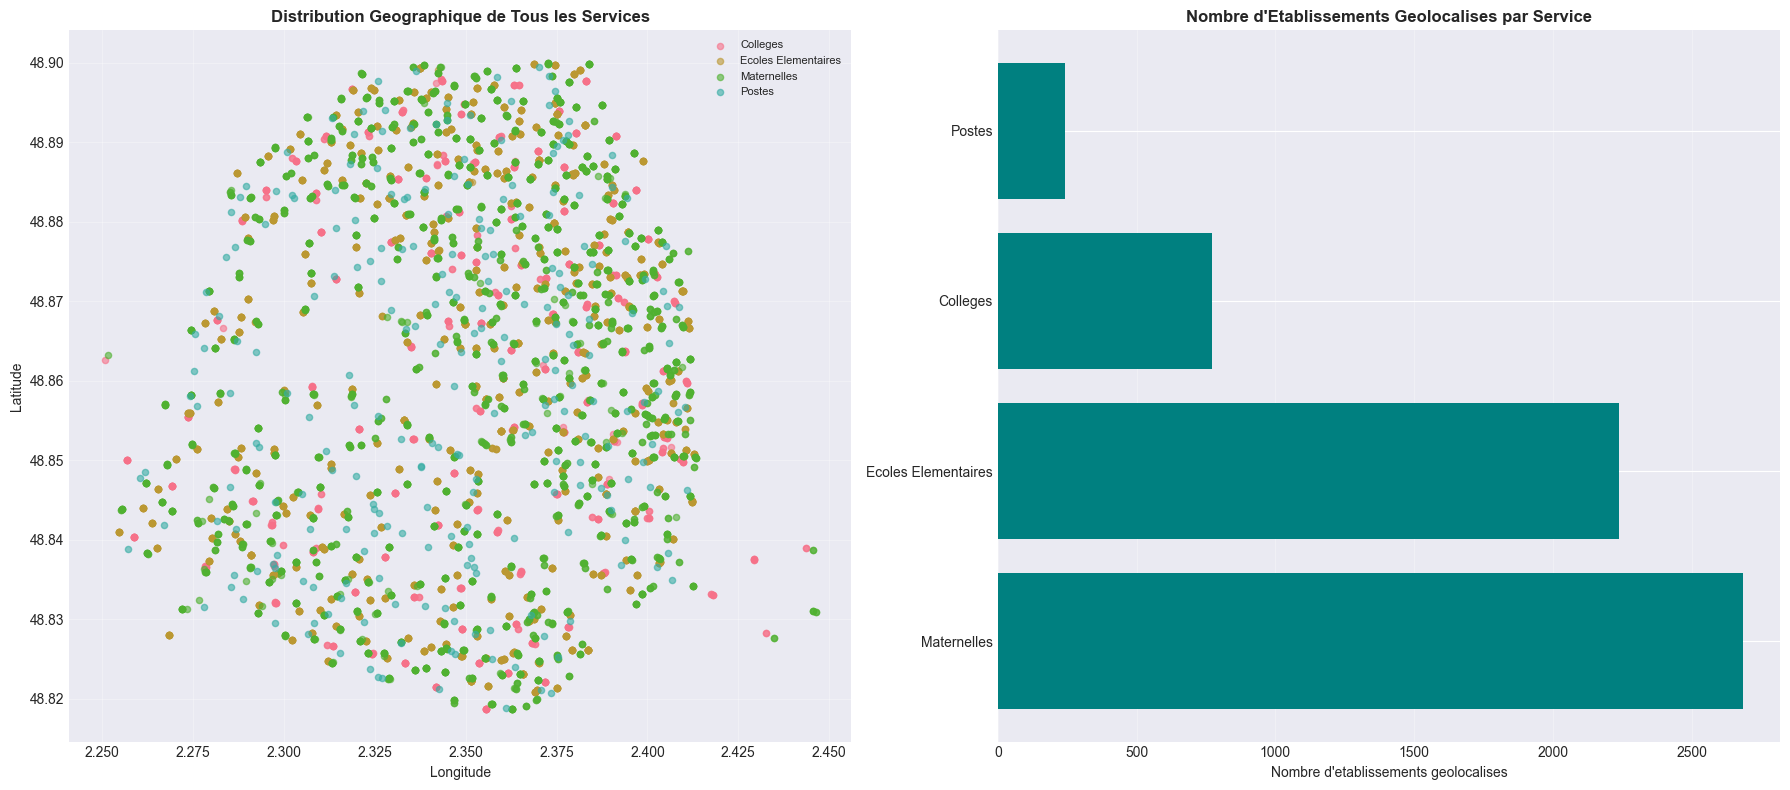

In [21]:
# Visualisation des etablissements sur une carte (scatter plot)
if all_coords:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Graphique 1: Tous les services sur une seule carte
    for service_name in df_all_coords['Service'].unique():
        service_coords = df_all_coords[df_all_coords['Service'] == service_name]
        axes[0].scatter(service_coords['Longitude'], service_coords['Latitude'], 
                       alpha=0.6, s=20, label=service_name)
    
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title('Distribution Geographique de Tous les Services', 
                      fontsize=12, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Graphique 2: Densite par type de service
    service_counts = df_all_coords['Service'].value_counts()
    axes[1].barh(range(len(service_counts)), service_counts.values, color='teal')
    axes[1].set_yticks(range(len(service_counts)))
    axes[1].set_yticklabels(service_counts.index)
    axes[1].set_xlabel('Nombre d\'etablissements geolocalises')
    axes[1].set_title('Nombre d\'Etablissements Geolocalises par Service', 
                      fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune coordonnee a visualiser")

## 15. Analyse Temporelle (Evolution par Annee Scolaire)

Analyse de l'evolution des etablissements scolaires par annee scolaire.

ANALYSE TEMPORELLE DES ETABLISSEMENTS SCOLAIRES

>>> Evolution par annee scolaire:


Type,Colleges,Ecoles Elementaires,Maternelles
Annee,,,
2020-2021,110.0,0.0,384.0
2021-2022,110.0,362.0,380.0
2022-2023,110.0,355.0,381.0
2023-2024,110.0,363.0,376.0
2024-2025,110.0,362.0,379.0
2025-2026,110.0,362.0,393.0
2026-2027,110.0,362.0,390.0


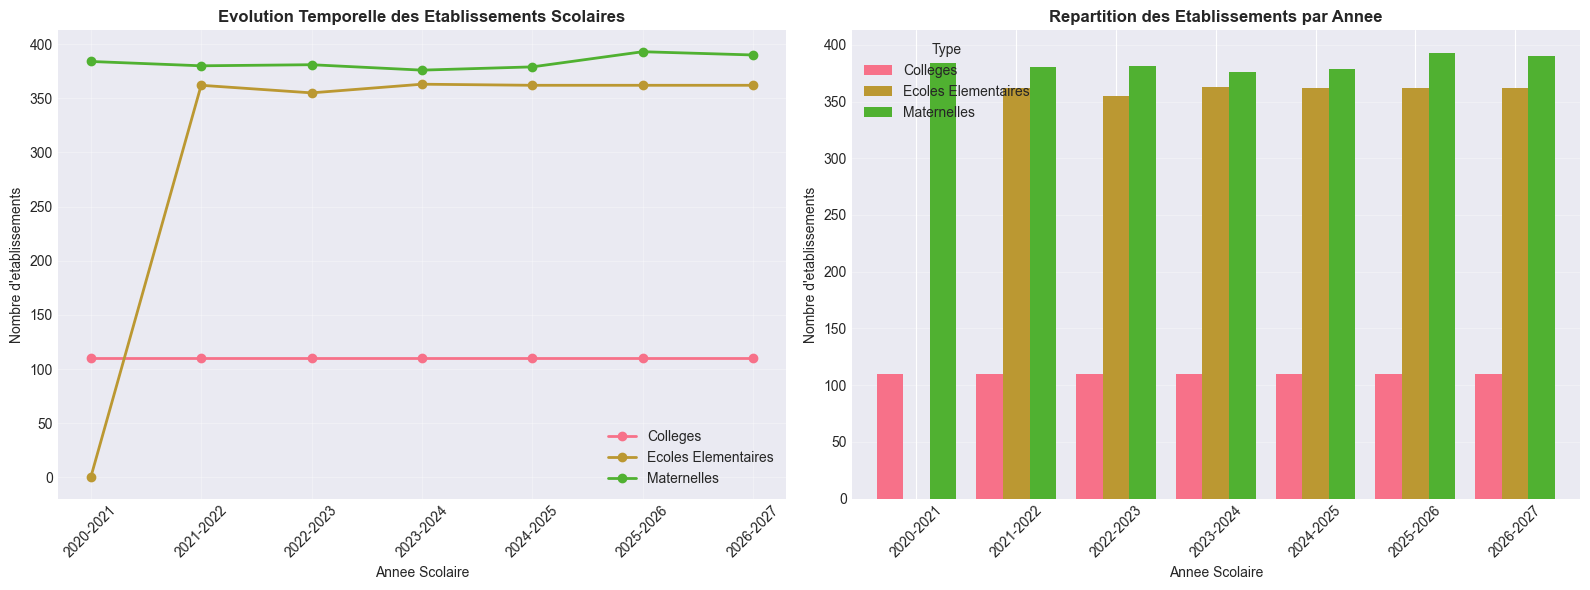

In [22]:
# Analyse temporelle pour les etablissements scolaires
temporal_data = []

school_datasets = {
    'Colleges': df_colleges,
    'Ecoles Elementaires': df_elementaires,
    'Maternelles': df_maternelles
}

for name, df in school_datasets.items():
    if len(df) > 0:
        # Recherche de colonne annee scolaire
        year_col = None
        for col in df.columns:
            col_lower = col.lower()
            if 'annee' in col_lower and 'scol' in col_lower:
                year_col = col
                break
        
        if year_col:
            year_counts = df[year_col].value_counts().sort_index()
            for year, count in year_counts.items():
                temporal_data.append({
                    'Annee': year,
                    'Type': name,
                    'Nombre': count
                })

if temporal_data:
    df_temporal = pd.DataFrame(temporal_data)
    
    print("=" * 80)
    print("ANALYSE TEMPORELLE DES ETABLISSEMENTS SCOLAIRES")
    print("=" * 80)
    
    # Tableau pivot
    pivot_temporal = df_temporal.pivot_table(
        index='Annee',
        columns='Type',
        values='Nombre',
        fill_value=0
    )
    
    print("\n>>> Evolution par annee scolaire:")
    display(pivot_temporal)
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique 1: Lignes
    for col in pivot_temporal.columns:
        axes[0].plot(pivot_temporal.index, pivot_temporal[col], marker='o', label=col, linewidth=2)
    
    axes[0].set_xlabel('Annee Scolaire')
    axes[0].set_ylabel('Nombre d\'etablissements')
    axes[0].set_title('Evolution Temporelle des Etablissements Scolaires', 
                      fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Graphique 2: Barres empilees
    pivot_temporal.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_xlabel('Annee Scolaire')
    axes[1].set_ylabel('Nombre d\'etablissements')
    axes[1].set_title('Repartition des Etablissements par Annee', 
                      fontsize=12, fontweight='bold')
    axes[1].legend(title='Type')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune donnee temporelle disponible")

## 16. Indicateurs de Couverture par Zone

Calcul des indicateurs de couverture des services publics par zone geographique.

INDICATEURS DE COUVERTURE PAR ARRONDISSEMENT

>>> Scores de couverture par arrondissement:
(Score = Total services / Nombre de types de services)


,Arrondissement,Total Services,Types de Services,Score Couverture
20,7520,261,1,261.0
18,7518,242,1,242.0
19,7519,239,1,239.0
13,7513,224,1,224.0
15,7515,171,1,171.0
17,7517,159,1,159.0
12,7512,127,1,127.0
16,7516,104,1,104.0
10,7510,99,1,99.0
9,7509,69,1,69.0


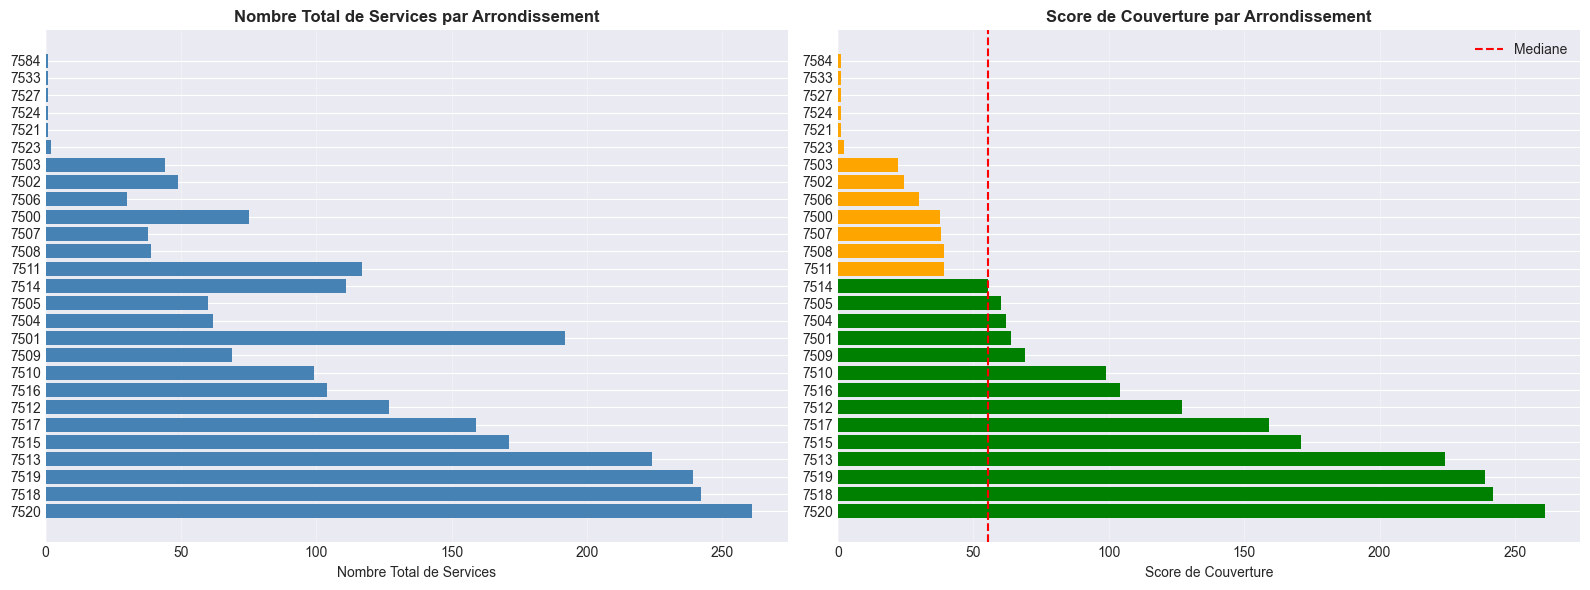


>>> Arrondissements sous-dotes (score < mediane 55.5):


,Arrondissement,Total Services,Types de Services,Score Couverture
11,7511,117,3,39.0
8,7508,39,1,39.0
7,7507,38,1,38.0
0,7500,75,2,37.5
6,7506,30,1,30.0
2,7502,49,2,24.5
3,7503,44,2,22.0
22,7523,2,1,2.0
21,7521,1,1,1.0
23,7524,1,1,1.0


In [23]:
# Calcul d'indicateurs de couverture
print("=" * 80)
print("INDICATEURS DE COUVERTURE PAR ARRONDISSEMENT")
print("=" * 80)

if densite_data:
    # Calcul du score de couverture par arrondissement
    coverage_scores = []
    
    for arr in pivot_densite.index:
        total_services = pivot_densite.loc[arr].sum()
        nb_types = (pivot_densite.loc[arr] > 0).sum()
        
        coverage_scores.append({
            'Arrondissement': arr,
            'Total Services': int(total_services),
            'Types de Services': int(nb_types),
            'Score Couverture': round(total_services / nb_types if nb_types > 0 else 0, 2)
        })
    
    df_coverage = pd.DataFrame(coverage_scores).sort_values('Score Couverture', ascending=False)
    
    print("\n>>> Scores de couverture par arrondissement:")
    print("(Score = Total services / Nombre de types de services)")
    display(df_coverage)
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique 1: Total services
    axes[0].barh(range(len(df_coverage)), df_coverage['Total Services'].values, color='steelblue')
    axes[0].set_yticks(range(len(df_coverage)))
    axes[0].set_yticklabels(df_coverage['Arrondissement'].values)
    axes[0].set_xlabel('Nombre Total de Services')
    axes[0].set_title('Nombre Total de Services par Arrondissement', 
                      fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Graphique 2: Score de couverture
    colors = ['green' if x >= df_coverage['Score Couverture'].median() else 'orange' 
              for x in df_coverage['Score Couverture']]
    axes[1].barh(range(len(df_coverage)), df_coverage['Score Couverture'].values, color=colors)
    axes[1].set_yticks(range(len(df_coverage)))
    axes[1].set_yticklabels(df_coverage['Arrondissement'].values)
    axes[1].set_xlabel('Score de Couverture')
    axes[1].set_title('Score de Couverture par Arrondissement', 
                      fontsize=12, fontweight='bold')
    axes[1].axvline(df_coverage['Score Couverture'].median(), 
                    color='red', linestyle='--', label='Mediane')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Identification des zones sous-dotees
    median_score = df_coverage['Score Couverture'].median()
    zones_sous_dotees = df_coverage[df_coverage['Score Couverture'] < median_score]
    
    print(f"\n>>> Arrondissements sous-dotes (score < mediane {median_score}):")
    display(zones_sous_dotees)
else:
    print("Donnees insuffisantes pour calculer les indicateurs de couverture")

## 17. Synthese des Metriques Cles

Tableau de bord recapitulatif avec les metriques cles pour l'indicateur service public.

TABLEAU DE BORD - SYNTHESE DES METRIQUES CLES

>>> Vue d'ensemble des datasets:


,Service,Nb Etablissements,Nb Colonnes,Completude (%),Geolocalisation
0,Colleges,770,14,85.88,Oui
1,Ecoles Elementaires,2237,9,99.65,Oui
2,Maternelles,2683,18,67.65,Oui
3,Bibliotheques,266,4,100.00,Non
4,Enseignement Superieur,86,92,56.41,Oui
5,Postes,241,24,92.25,Oui



>>> Statistiques agregees:
    Total d'etablissements recenses: 6283
    Moyenne de completude: 83.64%
    Datasets avec geolocalisation: 5 / 6


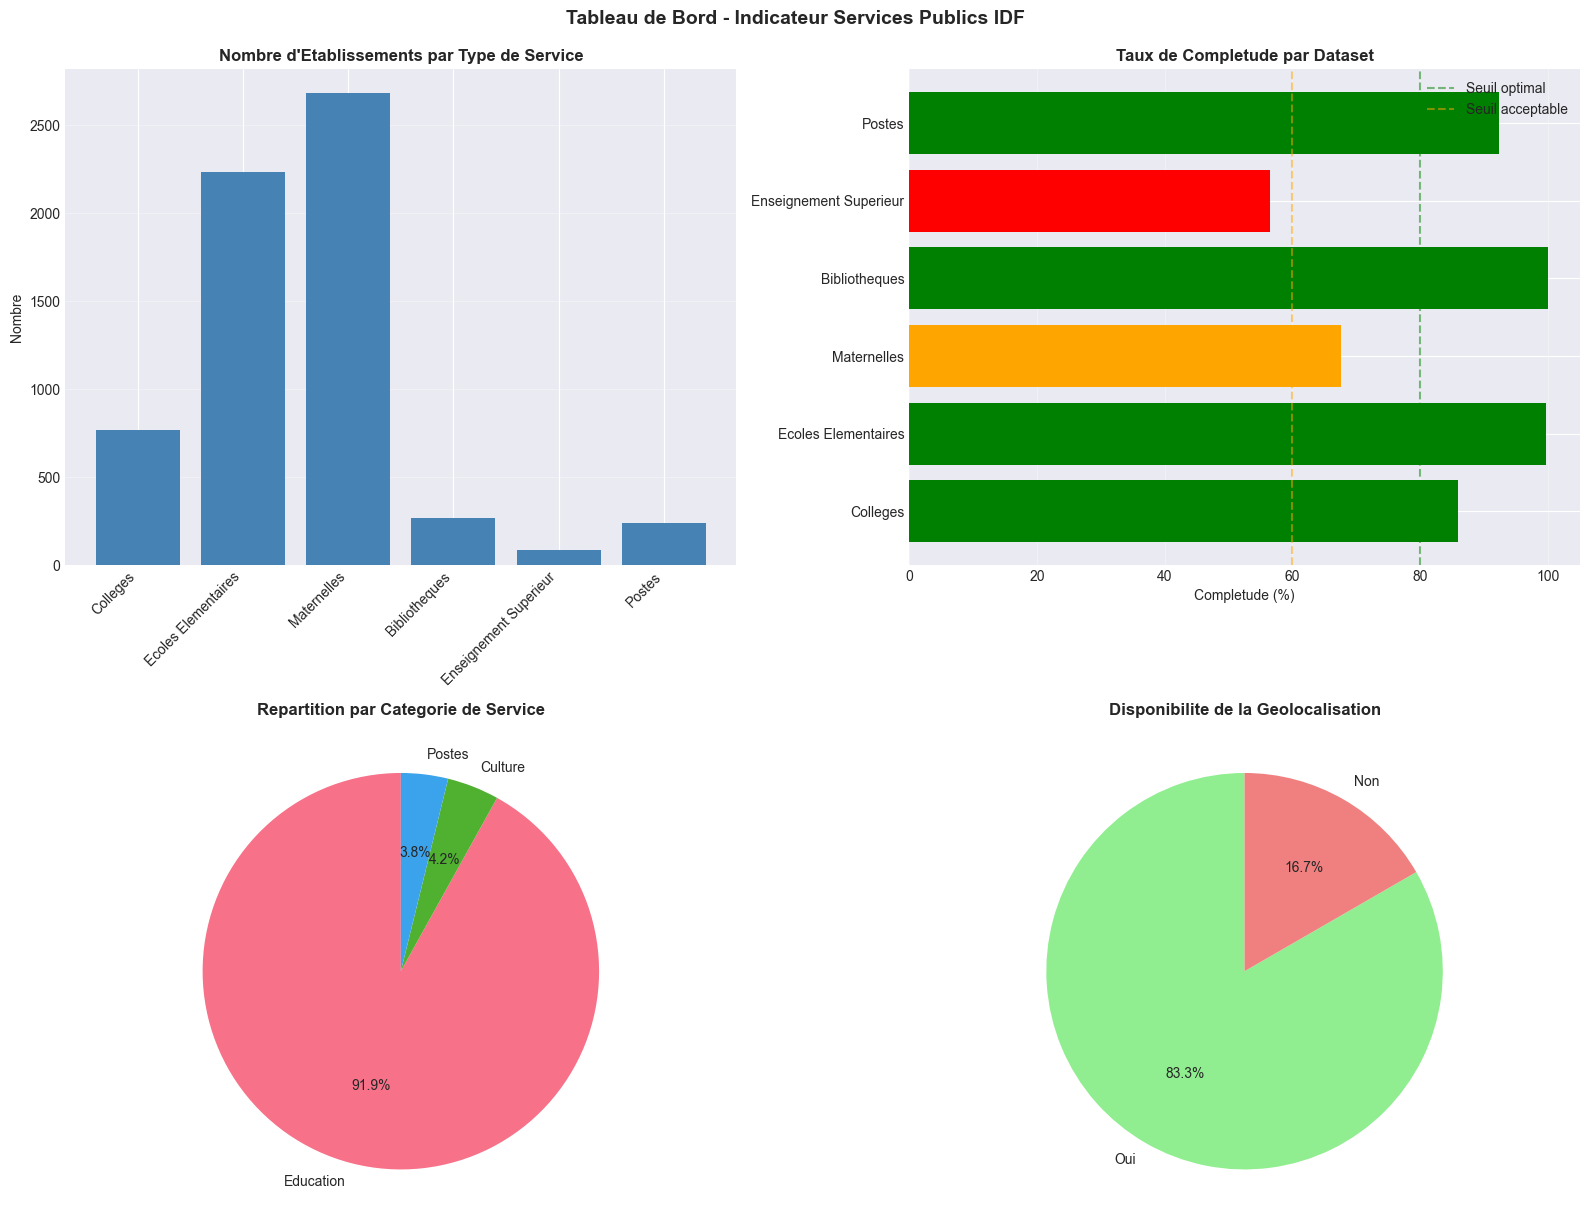

In [24]:
# Creation d'un tableau de bord de synthese
print("=" * 80)
print("TABLEAU DE BORD - SYNTHESE DES METRIQUES CLES")
print("=" * 80)

# Metriques globales
metriques_globales = []

for name, df in datasets.items():
    if len(df) > 0:
        nb_etablissements = len(df)
        nb_colonnes = len(df.columns)
        
        # Calcul du taux de completude
        completude = (1 - df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
        
        # Recherche de coordonnees
        has_coords = False
        for col in df.columns:
            col_lower = col.lower()
            if 'lat' in col_lower or 'lon' in col_lower or 'geo' in col_lower:
                has_coords = True
                break
        
        metriques_globales.append({
            'Service': name,
            'Nb Etablissements': nb_etablissements,
            'Nb Colonnes': nb_colonnes,
            'Completude (%)': round(completude, 2),
            'Geolocalisation': 'Oui' if has_coords else 'Non'
        })

df_metriques = pd.DataFrame(metriques_globales)

print("\n>>> Vue d'ensemble des datasets:")
display(df_metriques)

print(f"\n>>> Statistiques agregees:")
print(f"    Total d'etablissements recenses: {df_metriques['Nb Etablissements'].sum()}")
print(f"    Moyenne de completude: {df_metriques['Completude (%)'].mean():.2f}%")
print(f"    Datasets avec geolocalisation: {(df_metriques['Geolocalisation'] == 'Oui').sum()} / {len(df_metriques)}")

# Visualisation du tableau de bord
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Nombre d'etablissements par service
axes[0, 0].bar(range(len(df_metriques)), df_metriques['Nb Etablissements'].values, color='steelblue')
axes[0, 0].set_xticks(range(len(df_metriques)))
axes[0, 0].set_xticklabels(df_metriques['Service'].values, rotation=45, ha='right')
axes[0, 0].set_ylabel('Nombre')
axes[0, 0].set_title('Nombre d\'Etablissements par Type de Service', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Graphique 2: Completude des donnees
colors = ['green' if x >= 80 else 'orange' if x >= 60 else 'red' 
          for x in df_metriques['Completude (%)']]
axes[0, 1].barh(range(len(df_metriques)), df_metriques['Completude (%)'].values, color=colors)
axes[0, 1].set_yticks(range(len(df_metriques)))
axes[0, 1].set_yticklabels(df_metriques['Service'].values)
axes[0, 1].set_xlabel('Completude (%)')
axes[0, 1].set_title('Taux de Completude par Dataset', fontweight='bold')
axes[0, 1].axvline(80, color='green', linestyle='--', alpha=0.5, label='Seuil optimal')
axes[0, 1].axvline(60, color='orange', linestyle='--', alpha=0.5, label='Seuil acceptable')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Graphique 3: Repartition par categorie de service
categories = {
    'Education': ['Colleges', 'Ecoles Elementaires', 'Maternelles', 'Enseignement Superieur'],
    'Culture': ['Bibliotheques'],
    'Sante': ['Hopitaux'],
    'Securite': ['Police'],
    'Postes': ['Postes']
}

cat_counts = {}
for cat, services in categories.items():
    count = df_metriques[df_metriques['Service'].isin(services)]['Nb Etablissements'].sum()
    if count > 0:
        cat_counts[cat] = count

axes[1, 0].pie(cat_counts.values(), labels=cat_counts.keys(), autopct='%1.1f%%', 
               startangle=90, colors=sns.color_palette('husl', len(cat_counts)))
axes[1, 0].set_title('Repartition par Categorie de Service', fontweight='bold')

# Graphique 4: Disponibilite de la geolocalisation
geo_counts = df_metriques['Geolocalisation'].value_counts()
axes[1, 1].pie(geo_counts.values, labels=geo_counts.index, autopct='%1.1f%%',
               startangle=90, colors=['lightgreen', 'lightcoral'])
axes[1, 1].set_title('Disponibilite de la Geolocalisation', fontweight='bold')

plt.tight_layout()
plt.suptitle('Tableau de Bord - Indicateur Services Publics IDF', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 18. Conclusions et Recommandations

### Principales observations

L'analyse exploratoire des donnees sur les services publics en Ile-de-France revele plusieurs elements cles :

#### Points forts
- Couverture etendue des services educatifs (maternelles, elementaires, colleges)
- Disponibilite de donnees geographiques pour la majorite des services
- Richesse des metadonnees disponibles sur les plateformes OpenData

#### Points d'attention
- Certains datasets necessitent la configuration du serveur MCP (hopitaux, police)
- Presence de valeurs manquantes dans certaines colonnes cles
- Heterogeneite des formats de donnees entre les sources
